In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from PIL import Image
from skimage.measure import regionprops
from scipy.ndimage import label, distance_transform_edt
import nibabel as nib
from tqdm import tqdm

In [2]:
def calculate_surface_distances(labeled_mask):
    """
    Calculates the average distance from each instance's surface 
    to its nearest neighbor's surface.
    """
    num_instances = len(np.unique(labeled_mask)) - 1

    if num_instances < 2:
        return 0.0

    min_distances = []

    for i in range(1, num_instances + 1):
        current_instance_mask = (labeled_mask == i)

        dist_map = distance_transform_edt(~current_instance_mask)
        other_instances_mask = (labeled_mask > 0) & (labeled_mask != i)

        dist_to_neighbor = np.min(dist_map[other_instances_mask])
        min_distances.append(dist_to_neighbor)

    return np.mean(min_distances)


def collect_instance_metrics_from_mask(mask):
    """
    Analyzes individual instances within a single mask.
    Works for both 2D (YX) and 3D (ZYX).
    """
    is_3d = mask.ndim == 3
    conn = np.ones((3,) * mask.ndim, dtype=int)
    labeled_mask, n_instances = label(mask > 0, structure=conn)

    if n_instances == 0:
        return []

    instance_data = []

    props = regionprops(labeled_mask)
    all_instances_mask = (labeled_mask > 0)

    for p in props:
        curr_label = p.label
        if n_instances > 1:
            others_mask = all_instances_mask & (labeled_mask != curr_label)

            dist_map_to_others = distance_transform_edt(~others_mask)

            coords = p.coords
            min_dist = np.min(dist_map_to_others[coords[:, 0], coords[:, 1]]) if not is_3d else \
                np.min(dist_map_to_others[coords[:, 0],
                       coords[:, 1], coords[:, 2]])
        else:
            min_dist = np.inf  # No neighbors exist
        
        volume = p.area

        surface_area = p.perimeter if not is_3d else p.surface_area

        # Compactness/Sphericity ratio (standardized)
        if surface_area > 0:
            shape_index = (36 * np.pi * (volume**2)) / (surface_area **
                                                        3) if is_3d else (4 * np.pi * volume) / (surface_area**2)
        else:
            shape_index = 1.0

        coords = p.coords
        instance_data.append({
            'volume': volume,
            'shape_index': shape_index,
            'surface_area': surface_area,
            'solidity': p.solidity,  # Ratio of pixels in the region to pixels in the convex hull
            'min_neighbor_dist': min_dist,
            'centroid': p.centroid,
        })

    return instance_data

In [15]:
def collect_instance_metrics(base_path, task_name, splits=['train', 'val']):
    instance_rows = []
    image_rows = []

    for split in splits:
        # Path: Basepath/(split)/labels/(task)/
        label_dir = os.path.join(base_path, split, 'labels', task_name)

        if not os.path.exists(label_dir):
            print(f"Skipping {split}: Directory not found.")
            continue

        label_files = [f for f in os.listdir(label_dir) if f.endswith('.png')]

        for filename in tqdm(label_files):
            mask_path = os.path.join(label_dir, filename)
            mask = np.array(Image.open(mask_path))
            all_instance_data = collect_instance_metrics_from_mask(mask)
            image_rows.append({'split': split,
                          'class': task_name,
                          'filename': filename,
                          'im_size': mask.shape,
                          'n_instances': len(all_instance_data), })
            for instance_data in all_instance_data:
                instance_rows.append({'filename': filename} | instance_data)
    return pd.DataFrame(instance_rows), pd.DataFrame(image_rows)
    

LABEL_DIR = "../data/organelles/epfl"
TASK = "mit"

instance_metrics, image_metrics = collect_instance_metrics(LABEL_DIR, TASK)

100%|██████████| 82/82 [01:20<00:00,  1.02it/s]


In [16]:
instance_metrics["volume"].quantile([0.25, 0.5, 0.75])

0.25    1393.25
0.50    2265.00
0.75    3737.50
Name: volume, dtype: float64

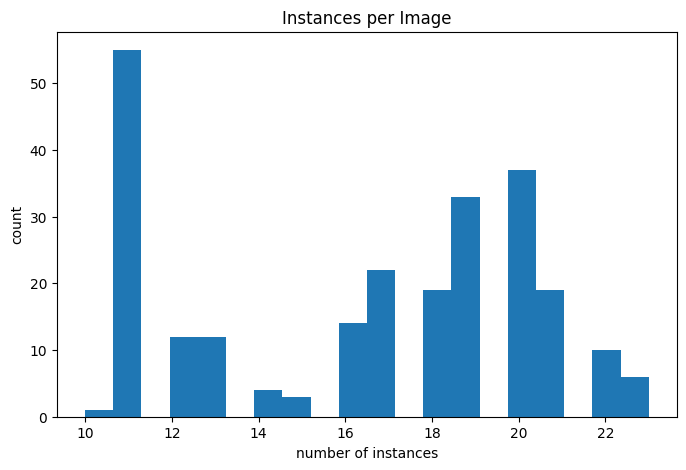

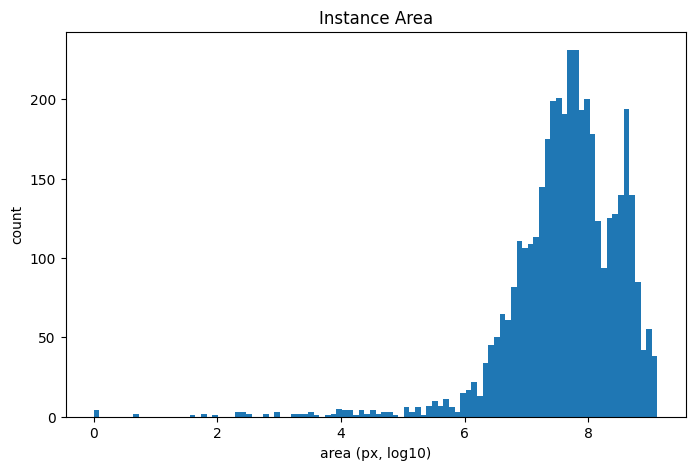

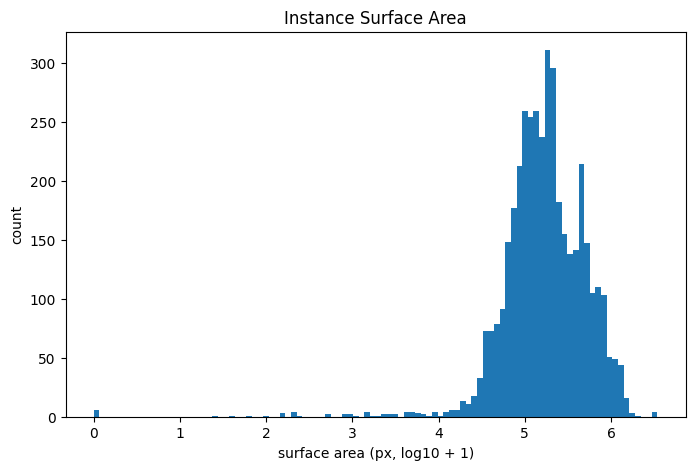

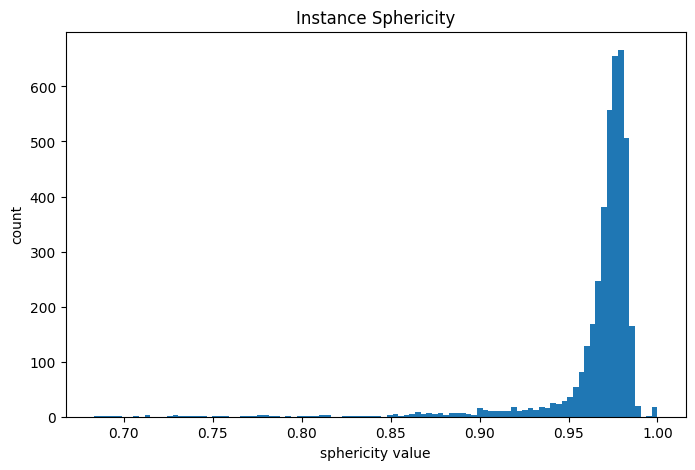

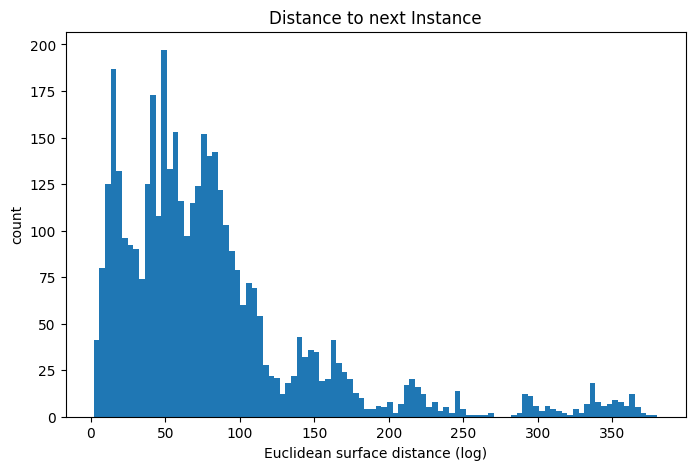

In [17]:
def plot_area_distribution(inst_df):
    plt.figure(figsize=(8, 5))

    vols = inst_df["volume"]

    plt.hist(np.log(vols), bins=100)

    plt.title("Instance Area")
    plt.xlabel("area (px, log10)")
    plt.ylabel("count")

    plt.show()


def plot_instances_per_image(im_df):
    plt.figure(figsize=(8, 5))

    n_inst = im_df["n_instances"]

    plt.hist(n_inst, bins = 20)

    plt.title("Instances per Image")
    plt.xlabel("number of instances")
    plt.ylabel("count")

    plt.show()


def plot_surface_area_distribution(inst_df):
    plt.figure(figsize=(8, 5))

    surfaces = inst_df["surface_area"]

    plt.hist(np.log(surfaces+1), bins=100)

    plt.title("Instance Surface Area")
    plt.xlabel("surface area (px, log10 + 1)")
    plt.ylabel("count")

    plt.show()
    

def plot_sphericity_distribution(inst_df):
    plt.figure(figsize=(8, 5))

    solidity = inst_df["solidity"]

    plt.hist(solidity, bins=100)

    plt.title("Instance Sphericity")
    plt.xlabel("sphericity value")
    plt.ylabel("count")

    plt.show()
    
def plot_nearest_neighbors_dist(inst_df):
    plt.figure(figsize=(8, 5))

    neigbor_dist = inst_df["min_neighbor_dist"]

    plt.hist(neigbor_dist, bins=100)

    plt.title("Distance to next Instance")
    plt.xlabel("Euclidean surface distance (log)")
    plt.ylabel("count")

    plt.show()
    
plot_instances_per_image(image_metrics)
plot_area_distribution(instance_metrics)
plot_surface_area_distribution(instance_metrics)
plot_sphericity_distribution(instance_metrics)
plot_nearest_neighbors_dist(instance_metrics)

In [52]:
def calculate_surface_distances(labeled_mask):
    """
    Calculates the average distance from each instance's surface 
    to its nearest neighbor's surface.
    """
    props = regionprops(labeled_mask)
    num_instances = len(props)

    if num_instances < 2:
        return 0.0

    min_distances = []

    for i in range(1, num_instances + 1):
        current_instance_mask = (labeled_mask == i)

        dist_map = distance_transform_edt(~current_instance_mask)
        other_instances_mask = (labeled_mask > 0) & (labeled_mask != i)
        
        dist_to_neighbor = np.min(dist_map[other_instances_mask])
        min_distances.append(dist_to_neighbor)

    return np.mean(min_distances)

def collect_instance_metrics_2d(base_path, task_name, splits=['train', 'val', 'test']):
    rows = []

    for split in splits:
        # Path: Basepath/(split)/labels/(task)/
        label_dir = os.path.join(base_path, split, 'labels', task_name)

        if not os.path.exists(label_dir):
            print(f"Skipping {split}: Directory not found.")
            continue

        label_files = [f for f in os.listdir(label_dir) if f.endswith('.png')]

        for filename in tqdm(label_files):
            mask_path = os.path.join(label_dir, filename)
            mask = np.array(Image.open(mask_path))

            labeled_mask, _ = label(mask > 0, np.ones((3, 3), dtype=np.int32))

            props = regionprops(labeled_mask)

            if not props:
                continue

            all_areas = np.array([p.area for p in props])
            avg_neighbor_dist = calculate_surface_distances(labeled_mask)
            rows.append({
                'split': split,
                'class': task_name,
                'filename': filename,
                'n_instances': len(all_areas),
                'all_areas': all_areas,
                'max_area': np.max(all_areas),
                'min_area': np.min(all_areas),
                'total_area': np.sum(all_areas),
                'total_area_share': np.sum(all_areas)/np.size(mask),
                'avg_nn_surface_dist': avg_neighbor_dist
            })

    return pd.DataFrame(rows)


def collect_instance_metrics_3d(label_dir, task_name):
    """
    Analyzes 3D NIfTI labels for instance metrics.
    Assumes binary masks (0 = background, >0 = instances).
    """
    rows = []

    label_files = [f for f in os.listdir(
        label_dir) if f.endswith(('.nii', '.nii.gz'))]

    if not label_files:
        print(f"No NIfTI files found in {label_dir}")
        return pd.DataFrame()

    for filename in label_files:
        file_path = os.path.join(label_dir, filename)

        img = nib.load(file_path)
        data = img.get_fdata()

        labeled_vol, _ = label(data > 0, np.ones((3, 3, 3), dtype=np.int32))
        props = regionprops(labeled_vol)

        if not props:
            continue

        all_volumes = np.array([p.area for p in props])

        rows.append({
            'split': 'all',
            'class': task_name,
            'filename': filename,
            'n_instances': len(all_volumes),
            'all_areas': all_volumes,
            'max_area': np.max(all_volumes),
            'min_area': np.min(all_volumes),
            'total_area': np.sum(all_volumes),
            'total_area_share': np.sum(all_volumes)/np.size(img)
        })

    return pd.DataFrame(rows)

In [37]:
LABEL_DIR = "../data/organelles/mitolab"
TASK = "mit"

df_metrics = collect_instance_metrics_2d(LABEL_DIR, TASK)

df_metrics.head()

 27%|██▋       | 1853/6739 [00:05<00:13, 349.48it/s]


KeyboardInterrupt: 

In [29]:
df = df_metrics.sort_values('min_area')
df["min_area"].quantile([0.01, 0.02, 0.03, 0.04, 0.05,
                        0.06, 0.07, 0.08, 0.09, 0.1])


def explode_instance_areas(df):
    """
    Convert dataframe from image-level to instance-level.
    Each instance area becomes its own row.
    """
    df_exp = df.copy()
    df_exp = df_exp.explode("all_areas")
    df_exp["all_areas"] = df_exp["all_areas"].astype(float)
    df_exp = df_exp.rename(columns={"all_areas": "instance_area"})
    return df_exp


inst_df = explode_instance_areas(df)

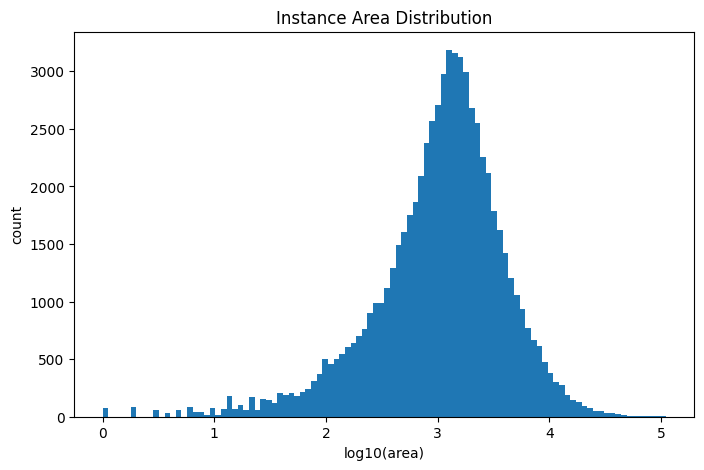

In [34]:
import matplotlib.pyplot as plt
import numpy as np


def plot_area_distribution(inst_df, log_scale=True):
    plt.figure(figsize=(8, 5))

    areas = inst_df["instance_area"]

    if log_scale:
        areas = np.log10(areas)

    plt.hist(areas, bins=100)

    plt.title("Instance Area Distribution")
    plt.xlabel("log10(area)" if log_scale else "area")
    plt.ylabel("count")

    plt.show()
    
def plot_smallest_percentiles(inst_df):
    percentiles = [0.001,0.005,0.01,0.02,0.05,0.1]
    values = inst_df["instance_area"].quantile(percentiles)

    plt.figure(figsize=(8,4))
    plt.plot(percentiles, values, marker="o")

    plt.title("Area Percentile Curve")
    plt.xlabel("percentile")
    plt.ylabel("instance area")

    plt.show()

    return values

plot_area_distribution(inst_df)

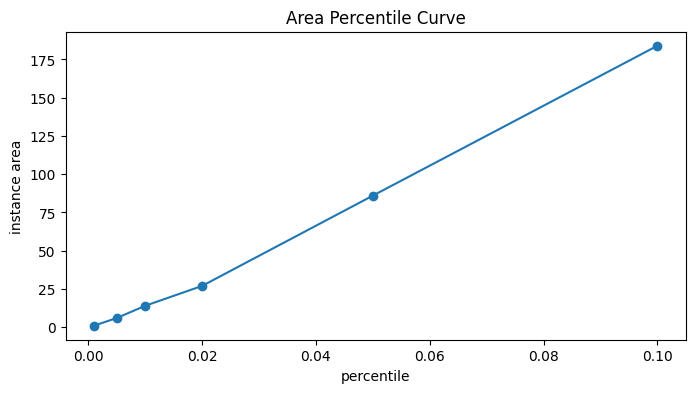

0.001      1.0
0.005      6.0
0.010     14.0
0.020     27.0
0.050     86.0
0.100    184.0
Name: instance_area, dtype: float64

In [31]:
plot_smallest_percentiles(inst_df)

In [32]:
def removal_impact(inst_df, thresholds=[1, 2, 4, 8, 16, 32]):
    results = []

    total_instances = len(inst_df)
    total_area = inst_df["instance_area"].sum()

    for t in thresholds:
        removed = inst_df[inst_df["instance_area"] <= t]

        results.append({
            "threshold": t,
            "instances_removed": len(removed),
            "instance_fraction_removed": len(removed) / total_instances,
            "area_removed": removed["instance_area"].sum(),
            "area_fraction_removed": removed["instance_area"].sum() / total_area
        })

    return pd.DataFrame(results)


removal_impact(inst_df)

,threshold,instances_removed,instance_fraction_removed,area_removed,area_fraction_removed
0,1,77,0.001141,77.0,5.315213e-07
1,2,158,0.002341,239.0,1.649787e-06
2,4,241,0.003571,516.0,3.561883e-06
3,8,473,0.007008,1975.0,1.363318e-05
4,16,895,0.013260,7423.0,5.124004e-05
5,32,1572,0.023290,23958.0,1.653791e-04


In [ ]:
import statistics
print(
    f'{statistics.mean(df_metrics['total_area_share'])} ± {statistics.stdev(df_metrics['total_area_share'])}')
print(
    f'{statistics.mean(df_metrics['avg_nn_surface_dist'])} ± {statistics.stdev(df_metrics['avg_nn_surface_dist'])}')

0.028888344594594596 ± 0.006171029540394779
28.592957400566693 ± 6.668691121751974


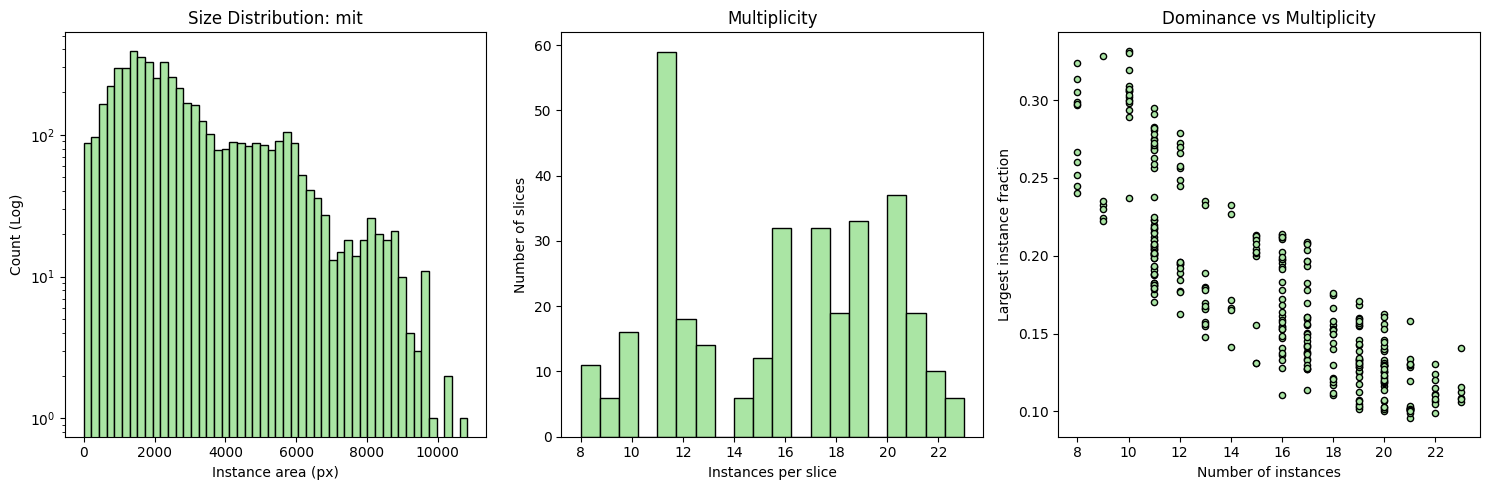

In [ ]:
if not df_metrics.empty:
    target_class = TASK
    class_df = df_metrics[df_metrics['class'] == target_class]
    all_areas = np.concatenate(class_df['all_areas'].values)
    largest_fractions = class_df["max_area"] / class_df["total_area"]

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.hist(all_areas, bins=50, color='#aae5a4', edgecolor='black', log=True)
    plt.xlabel("Instance area (px)")
    plt.ylabel("Count (Log)")
    plt.title(f"Size Distribution: {target_class}")

    plt.subplot(1, 3, 2)
    plt.hist(class_df["n_instances"], bins=20,
             color='#aae5a4', edgecolor='black')
    plt.xlabel("Instances per slice")
    plt.ylabel("Number of slices")
    plt.title("Multiplicity")

    plt.subplot(1, 3, 3)
    plt.scatter(class_df["n_instances"], largest_fractions,
                color='#aae5a4', edgecolor='black', alpha=1, s=20)
    plt.xlabel("Number of instances")
    plt.ylabel("Largest instance fraction")
    plt.title("Dominance vs Multiplicity")

    plt.tight_layout()
    plt.show()
else:
    print("No data found. Check your paths and file extensions.")